In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Distribution embedding

2026-05-06 09:41:08.935660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 09:41:09.526062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778053269.712719     730 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778053269.761497     730 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778053270.253444     730 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

{'000': 1, '001': 23, '010': 131, '011': 278, '100': 334, '101': 190, '110': 60, '111': 7}


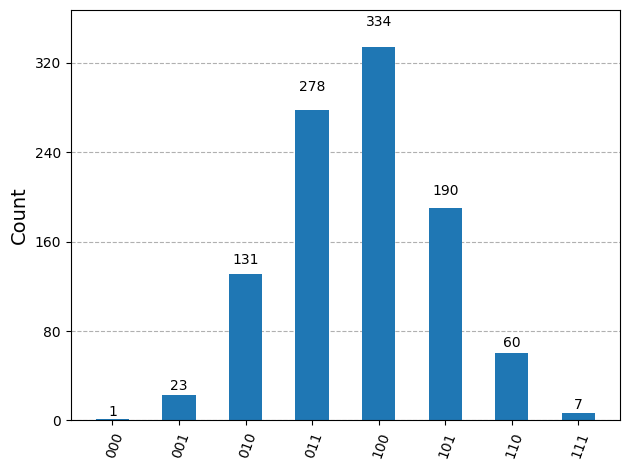

In [2]:
from qgan_lamarr import MinMaxBinning, SingleGaussian
num_qubits = 3
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _sample = SingleGaussian(shots = _size)
    return MinMaxBinning(_sample, _nbins)

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN evaluation

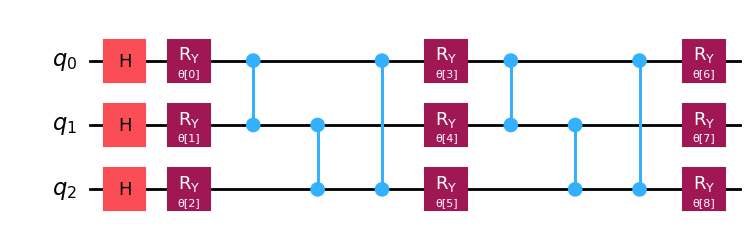

In [3]:
from qiskit.circuit import ParameterVector

reps = 2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length = (reps + 1) * num_qubits * 2)

p = 0

for q in range(num_qubits):
        qc.ry(theta[q], q)
        p += 1
for r in range(reps):

    for q in range(num_qubits):
        qc.cz(q%num_qubits, (q + 1)%num_qubits)
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1
        
    

qc.draw("mpl")

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

discriminator = Sequential([
    InputLayer(shape=(nbins,)),
    Dense(50),
    LeakyReLU(),
    Dense(1, activation='sigmoid') 
])

discriminator.summary()

2026-04-15 09:54:09.069205: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 09:54:09.081780: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776239649.096199    2851 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776239649.100295    2851 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776239649.110799    2851 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from qgan_lamarr import QGAN
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [6]:
epochs = 4000
model.discriminator_lr = 1e-2
model.fit(epochs = epochs, shots = 2**10, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260415_095412
Training started


100%|██████████| 4000/4000 [12:28<00:00,  5.35it/s]

Training completed


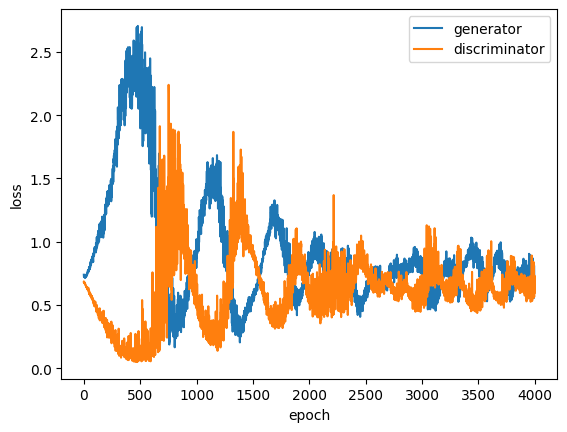

In [7]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

Text(0.5, 1.0, 'Kolmogorov-Smirnov statistic test')

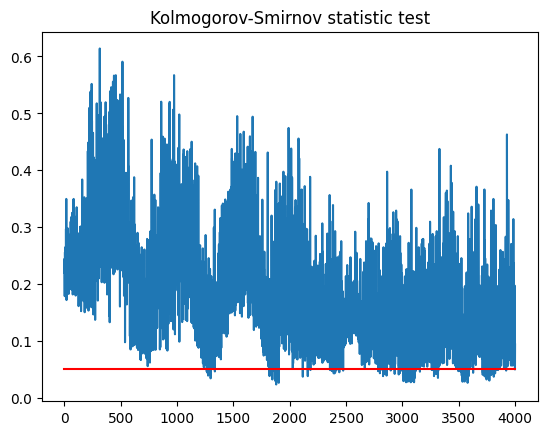

In [8]:
plt.plot(model.metrics['kolmogorov_smirnov'])
plt.plot([0, epochs],[0.051, 0.051], color = 'RED')
plt.title('Kolmogorov-Smirnov statistic test')